# Projeto de análise sensorial do café. 

## 1. Apresentação da base de dados e contexto.

### Contexto do projeto

Este projeto utiliza a base de dados `df_arabica_clean.csv`, que contém informações detalhadas sobre a avaliação de qualidade de cafés arábica de diversas partes do mundo. Os dados incluem a origem do grão, método de processamento, e notas sensoriais dadas por especialistas (Armoma, sabor, acidez, corpo, etc).

### Objetivo

O objetivo deste projeto é construir um modelo de Machine Learning capaz de prever a pontuação total do café (`Total Cup Points`) com base em suas caracteristicas sensoriais. Essa abordagem pode ajudar produtores a entender quais características (como sabor ou acidez) têm maior peso na nota final do seu produto.

##### Import de bibliotecas necessárias. 

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

## 2. Análise exploratória de dados.

##### Carregamento da base de dados com tratamento de erro.

In [78]:
try:
    cafe = pd.read_csv('df_arabica_clean.csv')
    print("Arquivo carregado com sucesso!")
except FileNotFoundError:
    print("Erro: arquivo df_arabica_clean.csv não encontrado!")


Arquivo carregado com sucesso!


##### Exibindo as primeiras linhas para entendimento da estrutura.

In [79]:
display(cafe.head())

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


##### Selecionando as variáveis numéricas de interesse para a análise.

In [98]:
colunas_interesse = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total Cup Points']
cafe_analise = cafe[colunas_interesse].dropna().copy()
display(cafe_analise.describe())

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Total Cup Points
count,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000
mean,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,83.706570
std,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,1.730417
min,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,78.000000
25%,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,82.580000
50%,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,83.750000
75%,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,84.830000
max,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,89.330000


Através da função `describe()`, pode-se observar a mádia das notas sensoriais e da nota final (`Total Cup Pints`), bem como o desvio padrão, o que nos indica a dispersão da qualidade dos cafés avaliados. Nota-se que a maioria dos cafés possui notas sensoriais orbitando em torno de 7.5 a 8.5.  

##### Separando as variáveis independentes (X)

In [81]:
X = cafe_analise[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']]

print("Dados carregados com sucesso! Quantidade de registros:", len(cafe_analise))

Dados carregados com sucesso! Quantidade de registros: 207


## 3. Visualização gráfica e relações.

##### Gráfico 1: Histograma da variável alvo (Total Cup Points)

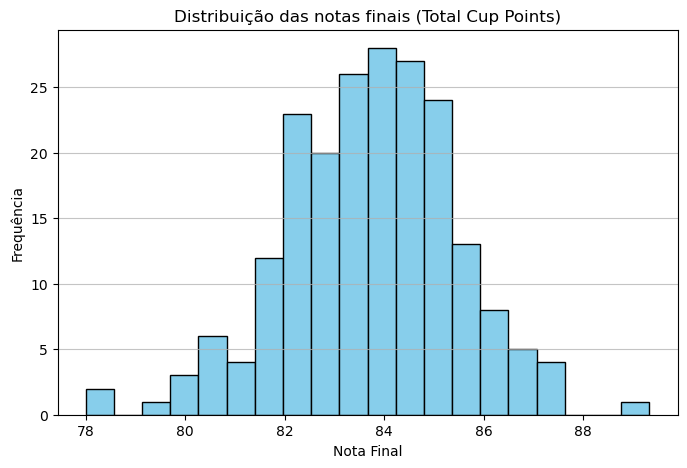

In [82]:
plt.figure(figsize=(8, 5))
plt.hist(cafe['Total Cup Points'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuição das notas finais (Total Cup Points)')
plt.xlabel('Nota Final')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### Gráfico 2: Relação entre sabor (flavor) e nota final

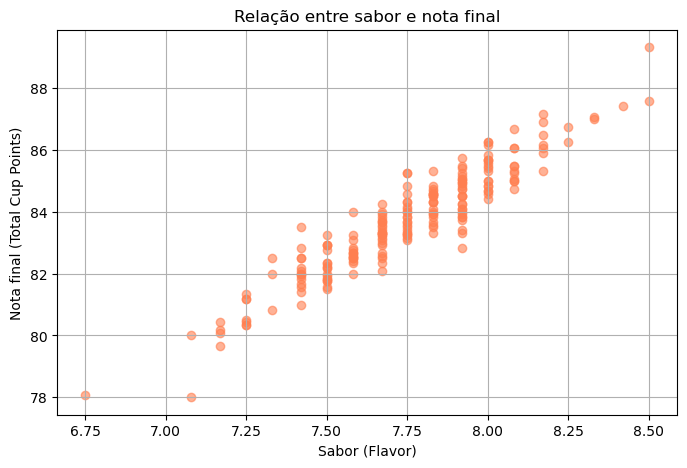

In [83]:
plt.figure(figsize=(8, 5))
plt.scatter(cafe['Flavor'], cafe['Total Cup Points'], color='coral', alpha=0.6)
plt.title('Relação entre sabor e nota final')
plt.xlabel('Sabor (Flavor)')
plt.ylabel('Nota final (Total Cup Points)')
plt.grid(True)
plt.show()

O histograma mostra como as notas finais estão distribuídas, com uma concentração evidennte entre 82 e 86 pontos. O gráfico de dispersão (scatter plot) demonstra uma forte correlação linear positiva entre 'Flavor' (Sabor) e a nota final do café, idicando que o sabor é uma exelente preditor para o modelo.

## 4. Criação de modelos de machine learning.

Para demonstrar uma análise completa da base de dados, será aplicado três abordagens diferentes de machine learning: clustering (agrupamento), classificação e regressão.

<!-- **Justificativa do modelo:**

Optamos por um modelo de *Clustering* utilizando o algoritmo *K-Means*. O objetivo é decobrir se os dados se agrupam naturalmente em diferentes "perfis sensoriais" de café (por exemplo: cafés de qualidade excepcional, qualidade média e qualidade inferior) baseando-se apenas nas suas notas de sabor, aroma, acidez, etc., sem utilizar a nota final previamente.

**Sobre o método:**

Como o K-Means calcula distâncias matemáticas, é fundamental normalizar os dados antes. A divisão em treino e teste será feita para treinar os centróides no conjunto de treino e validar a consistência do agrupamento no conjunto de teste. A métrica de avaliação utilizada será o *Silhouette Score* (que mede o quão bem separados estão os clusters, substituindo as métricas de erro tradicionais de modelos supervisionados).

<!--
Como a variável alvo (`Total Cup Points`) é um valor numérico contínuo, então se tatra de um problema de *regressão*. Foi escolhido o modelo de *Regressão Linear Múltipla* (Utilizando a biblioteca `scikit-learn`) devido à forte relação linear observada na análise gráfica e pela facilidade de interpretação dos coeficientes.
-->

### 4.1 Modelo 1: Clustering (K-Means)

**Objetivo:** Descobrir perfis sensoriais de café agrupando-os por similaridade, sem olhar a nota final.

Como o K-Means calcula distância matemática, é fundamental normalizar os dados antes. A métrica de avaliação utiliza será o *Silhouette Score* (que não mede quão bem separados estão os clusters).

##### Evitando avisos do KMeans

In [84]:
warnings.filterwarnings('ignore')

##### Separação da variáveis preditoras (X) e da variável alvo (Y).

In [85]:
x = cafe_analise[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']]
y = cafe_analise['Total Cup Points']

##### Padronização de dados (crucial para o K-Means).

In [86]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

##### Treinamento do modelo K-Means (buscando 3 perfis de café).

In [87]:
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cafe_analise['Cluster'] = modelo_kmeans.fit_predict(x_scaled)

##### Avaliação do agrupamento.

In [88]:
score_silhueta = silhouette_score(x_scaled, cafe_analise['Cluster'])
print(f"Silhouette Score (Qualidade da separação): {score_silhueta:.4f}")

Silhouette Score (Qualidade da separação): 0.3266


##### Exibindo a média das notas sensoriais para entender o perfil de cada Cluster.

In [89]:
display(cafe_analise.groupby('Cluster')[['Aroma', 'Flavor', 'Acidity']].mean().round(2))

,Aroma,Flavor,Acidity
Cluster,,,
0,7.38,7.37,7.35
1,7.99,8.01,7.92
2,7.66,7.70,7.66


### 4.2 Modelo 2: Classificação (Regressão logística)

**Objetivo:** Prever se o café é "Premium" (nota final >= 83 pontos) baseado apenas em suas caracteristicas sensoriais.

Transformamos a variável contínua da nota final em uma categoria (0 para padrão, 1 para premium) para treinar o classificador.

##### Criando a variável alvo categórica (1 = Premium, 0 = Padrão)

In [90]:
cafe_analise['Premium'] = (cafe_analise['Total Cup Points'] >= 83.0).astype(int)
y_class = cafe_analise['Premium']

##### Seperação em dados de treino e teste.

In [91]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_scaled, y_class, test_size=0.2, random_state=42)

##### Instanciando e treinando o modelo.

In [92]:
modelo_classificacao = LogisticRegression()
modelo_classificacao.fit(x_train_c, y_train_c)

LogisticRegression()

##### Prediçoes e métricas.

In [93]:
y_pred_c = modelo_classificacao.predict(x_test_c)
print("Relatório de classificação (previsão de café premium):")
print(classification_report(y_test_c, y_pred_c))

Relatório de classificação (previsão de café premium):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        26

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.97        42
weighted avg       0.98      0.98      0.98        42



### 4.3 Modelo 3: Regressão (regressão linear mútipla)

**Objetivo:** Prever o valor numérico exato da nota final (`Total Cup Points`) de um café.

Devido a forte relação linear observada na análise gráfica (Sabor vs Nota Final), a regressão linear múltipla é ideal para prever a pontuação exata baseada no conjunto de notas sensoriais.

##### Separação em dados de treino (80%) e teste (20%).

In [94]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##### Instanciando e treinando o modelo.

In [95]:
modelo_regressao = LinearRegression()
modelo_regressao.fit(x_train, y_train)

LinearRegression()

##### Descrições da métrica de erro.

In [96]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.4f}")
print(f"Erro absoluto médio (MAE): {mae:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")

Erro quadrático médio (MSE): 0.0116
Erro absoluto médio (MAE): 0.0858
Coeficiente de determinação (R²): 0.9954


As métricas avaliam a precisão do modelo. O R² próximo a 1 indicará o quanto da variância da nota final é explicada pelas notas sensoriais conjuntas.

##### Exemplo de uso: Prevendo a nota de um café hipotético criado.

**Notas hipotéticas:**

- Aroma: 8.0;
- Flavor: 8.2;
- Aftertaste: 8.1;
- Acidity: 7.9;
- Body: 8.0;
- Balance: 8.0.

In [97]:
novo_cafe = np.array([[8.0, 8.2, 8.1, 7.9, 8.0, 8.0]])
previsao = modelo_regressao.predict(novo_cafe)

print(f"A nota final prevista para o café hipotético é: {previsao[0]:.2f} pontos.")

A nota final prevista para o café hipotético é: 86.28 pontos.
